# Task 4: Predicting Insurance Claim Amounts

## Introduction

The objective of this project is to predict medical insurance charges using Linear Regression. The project includes data preprocessing, exploratory data analysis (EDA), feature encoding, regression modeling, and model evaluation.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv("insurance.csv")

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.shape

(1338, 7)

In [5]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


## Dataset Understanding

The dataset contains demographic and health-related information about individuals, including age, BMI, smoking status, and region. The target variable is **charges**, representing the medical insurance claim amount.

In [9]:
# Check missing values

df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [11]:
# Check duplicate rows

df.duplicated().sum()

np.int64(1)

## Data Cleaning

The dataset was examined for missing values and duplicate records. No missing values were found, and the data was ready for further analysis.

## Exploratory Data Analysis (EDA)

EDA was performed to understand how different factors influence medical insurance charges.

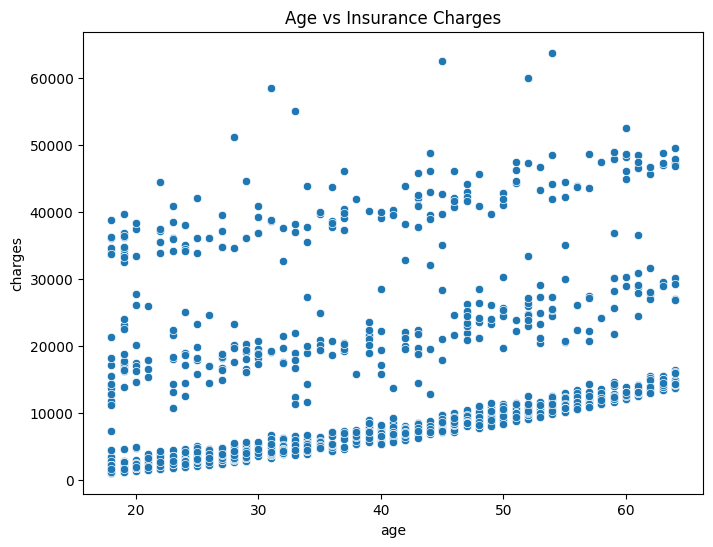

In [12]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='age',
    y='charges'
)

plt.title("Age vs Insurance Charges")

plt.show()

### Observation

Insurance charges generally increase with age. Older individuals tend to have higher medical insurance costs than younger individuals.

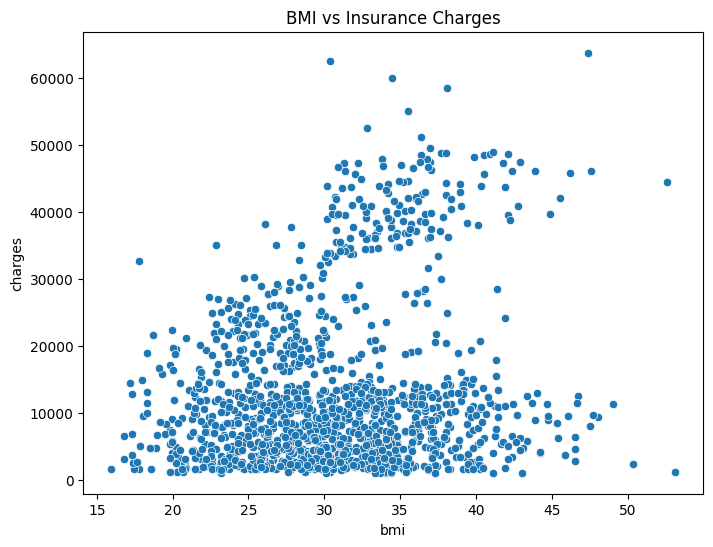

In [13]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='bmi',
    y='charges'
)

plt.title("BMI vs Insurance Charges")

plt.show()

### Observation

Individuals with higher BMI values often have higher insurance charges, although the relationship is not perfectly linear.

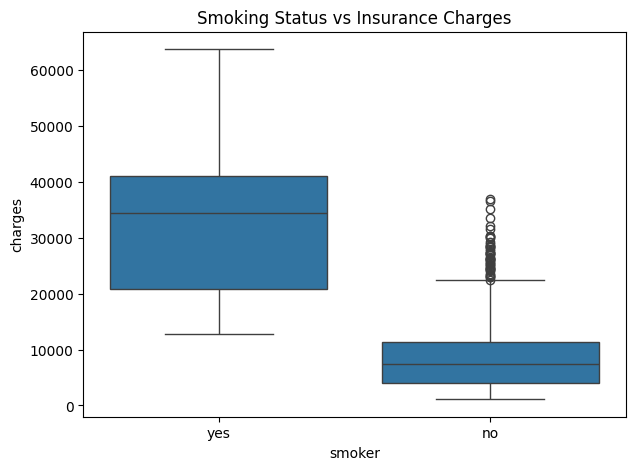

In [14]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='smoker',
    y='charges'
)

plt.title("Smoking Status vs Insurance Charges")

plt.show()

### Observation

Smokers have significantly higher medical insurance charges than non-smokers, indicating that smoking is a major factor influencing insurance costs.

## Feature Encoding

Categorical variables were converted into numerical values using Label Encoding to prepare the data for regression modeling.

In [15]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['sex'] = encoder.fit_transform(df['sex'])

df['smoker'] = encoder.fit_transform(df['smoker'])

df['region'] = encoder.fit_transform(df['region'])

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [17]:
# Separate features and target variable

X = df.drop('charges', axis=1)

y = df['charges']

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

## Model Training

A Linear Regression model was selected to predict medical insurance charges based on customer characteristics.

In [19]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [20]:
# Predictions

y_pred = model.predict(X_test)

In [21]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, y_pred)

rmse = mean_squared_error(y_test, y_pred) ** 0.5

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)

print("RMSE:", rmse)

print("R2 Score:", r2)

MAE: 4186.508898366435
RMSE: 5799.587091438356
R2 Score: 0.7833463107364539


### Model Performance

The Linear Regression model achieved a Mean Absolute Error (MAE) of **4186.51**, a Root Mean Squared Error (RMSE) of **5799.59**, and an R² Score of **0.7833**. These results indicate that the model performs well in estimating medical insurance charges based on customer characteristics.

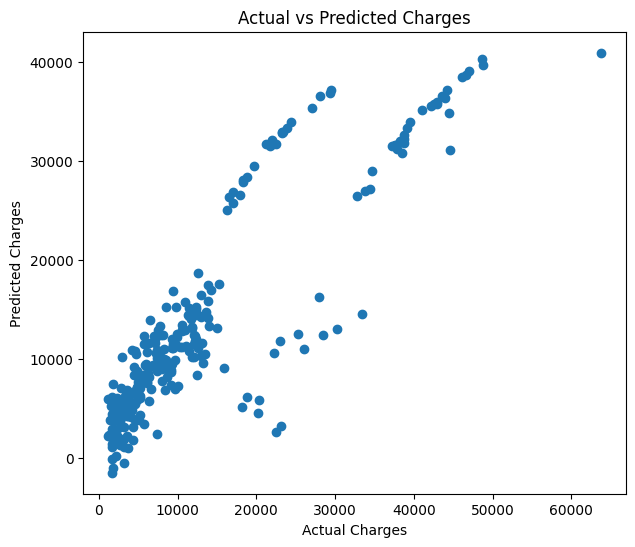

In [22]:
# Actual vs Predicted

plt.figure(figsize=(7,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Charges")

plt.ylabel("Predicted Charges")

plt.title("Actual vs Predicted Charges")

plt.show()

## Conclusion

In this project, a Linear Regression model was developed to estimate medical insurance charges. Exploratory Data Analysis (EDA) showed that age, BMI, and smoking status significantly influence insurance costs. The model was evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score, demonstrating the practical application of regression techniques in predicting insurance claim amounts.